# AI CV Analyzer — Complete ML Pipeline
## BTS Applied ML 2026

This notebook covers **two distinct pipelines**:

| Pipeline | Task | Type |
|---|---|---|
| **Pipeline 1** | Job Category Classification | Multi-class text classification (24 classes) |
| **Pipeline 2** | CV ↔ Job Matching | Information retrieval (cosine similarity) |

Each pipeline is evaluated independently with multiple models and metrics.

In [3]:
# Run this cell first — installs all required packages
%pip install "kagglehub==0.3.4"
%pip install torch>=2.0.0 scikit-learn>=1.3.0 joblib>=1.3.0
%pip install pandas>=2.0.0 numpy>=1.24.0 nltk>=3.8.0
%pip install matplotlib>=3.7.0 seaborn>=0.12.0 plotly>=5.15.0
%pip install pdfplumber>=0.10.0 PyMuPDF>=1.24.0 tqdm>=4.65.0 wordcloud>=1.9.0

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
print('All packages installed and NLTK data downloaded.')

  Using cached kagglehub-0.3.4-py3-none-any.whl.metadata (22 kB)
Using cached kagglehub-0.3.4-py3-none-any.whl (43 kB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
All packages installed and NLTK data downloaded.


## 0. Setup & Imports

In [4]:
import sys, os, warnings, time
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter

import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report, confusion_matrix)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics.pairwise import cosine_similarity

from src.dataset import (load_dataset, load_job_descriptions, prepare_data,
                          clean_text, Vocabulary, ResumeDataset)
from src.model import LSTMClassifier, GRUClassifier, count_parameters
from src.train import train_baseline, train_deep
from src.evaluate import plot_training_curves

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("All imports OK")
print(f"PyTorch: {torch.__version__}")

All imports OK
PyTorch: 2.6.0+cpu


## 1. Download Datasets (Kaggle via kagglehub)

In [5]:
import kagglehub, glob

print("Downloading resume dataset...")
resume_dir = kagglehub.dataset_download('snehaanbhawal/resume-dataset')
RESUME_CSV = glob.glob(os.path.join(resume_dir, '**', '*.csv'), recursive=True)[0]
print(f"  Resume CSV: {RESUME_CSV}")

print("Downloading job descriptions dataset...")
jobs_dir = kagglehub.dataset_download('ravindrasinghrana/job-description-dataset')
JOBS_CSV = glob.glob(os.path.join(jobs_dir, '**', '*.csv'), recursive=True)[0]
print(f"  Jobs CSV: {JOBS_CSV}")

  Resume CSV: C:\Users\MSI\.cache\kagglehub\datasets\snehaanbhawal\resume-dataset\versions\1\Resume\Resume.csv
  Jobs CSV: C:\Users\MSI\.cache\kagglehub\datasets\ravindrasinghrana\job-description-dataset\versions\1\job_descriptions.csv


## 2. Dataset Exploration

### Resume Dataset (used for Pipeline 1)

In [6]:
df = load_dataset(RESUME_CSV)
print(f"Shape: {df.shape}")
print(f"Categories ({df['Category'].nunique()}):\n")
counts = df['Category'].value_counts()
for cat, n in counts.items():
    print(f"  {cat:<30} {n:>4} resumes")

[Dataset] Loaded 2484 resumes, 24 categories
          Categories: ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']
Shape: (2484, 2)
Categories (24):

  INFORMATION-TECHNOLOGY          120 resumes
  BUSINESS-DEVELOPMENT            120 resumes
  ADVOCATE                        118 resumes
  CHEF                            118 resumes
  ENGINEERING                     118 resumes
  ACCOUNTANT                      118 resumes
  FINANCE                         118 resumes
  FITNESS                         117 resumes
  AVIATION                        117 resumes
  SALES                           116 resumes
  BANKING                         115 resumes
  HEALTHCARE                      115 resumes
  CONSULTANT               

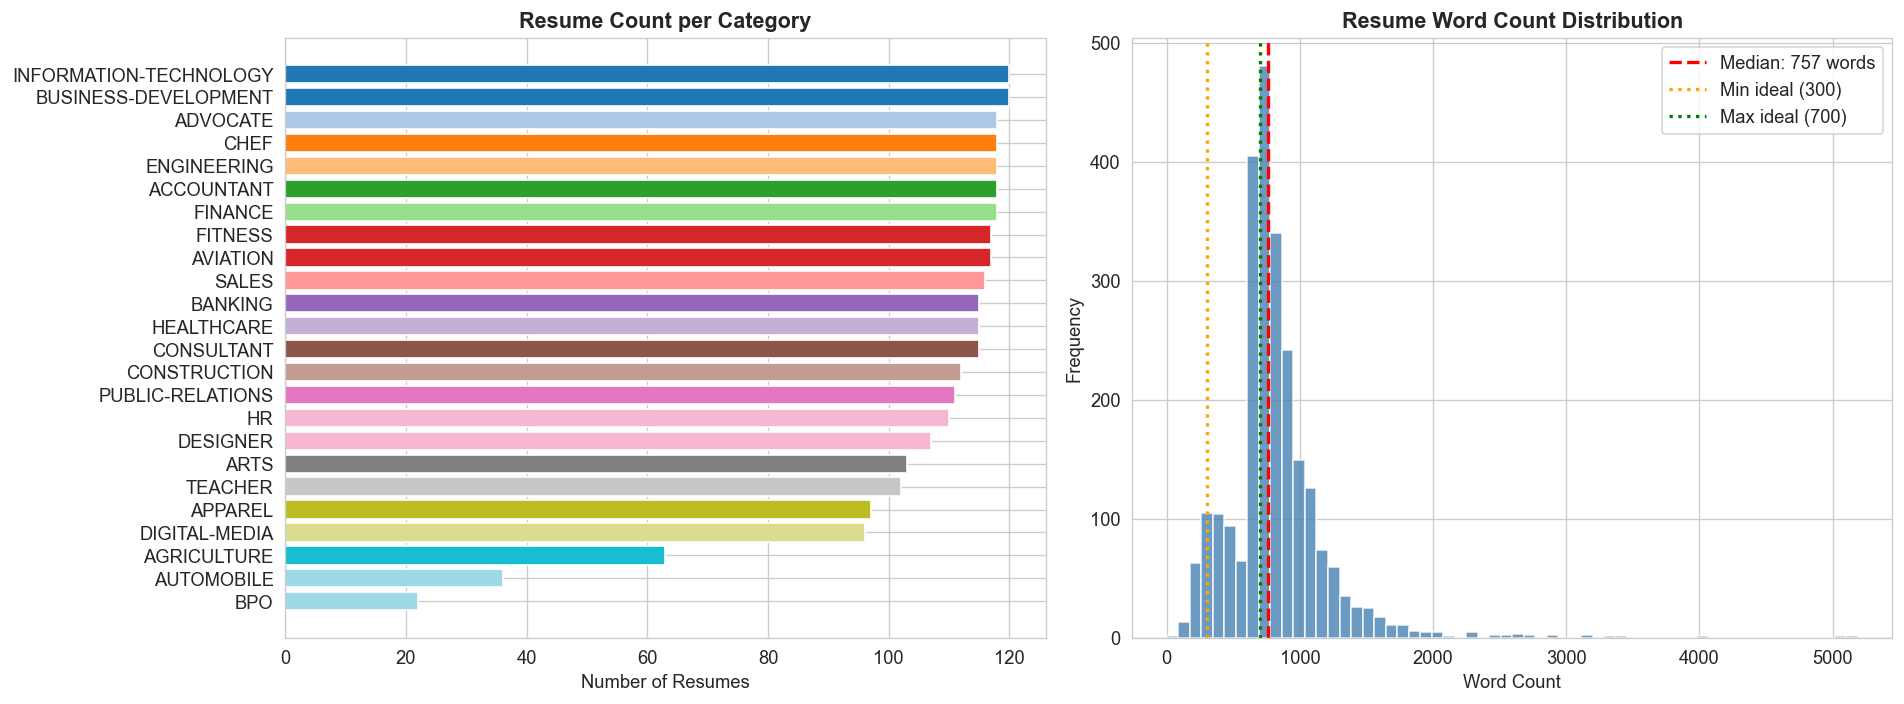

Word count: min=0 | median=757 | max=5190


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Class distribution
counts = df['Category'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_title('Resume Count per Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Resumes')
axes[0].invert_yaxis()

# Word count distribution
df['word_count'] = df['Resume_str'].str.split().str.len()
axes[1].hist(df['word_count'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', linewidth=2,
                label=f"Median: {df['word_count'].median():.0f} words")
axes[1].axvline(300, color='orange', linestyle=':', linewidth=2, label='Min ideal (300)')
axes[1].axvline(700, color='green', linestyle=':', linewidth=2, label='Max ideal (700)')
axes[1].set_title('Resume Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Word count: min={df['word_count'].min()} | median={df['word_count'].median():.0f} | max={df['word_count'].max()}")

## 3. Text Preprocessing

Pipeline applied to every resume:
1. Lowercase
2. Remove URLs and emails
3. Replace numbers with `NUM` token
4. Remove punctuation
5. Remove English stopwords
6. Remove tokens shorter than 3 characters

In [8]:
sample = df.iloc[5]['Resume_str']
print("=== RAW TEXT (first 500 chars) ===")
print(sample[:500])
print()
print("=== AFTER PREPROCESSING (first 500 chars) ===")
print(clean_text(sample)[:500])

=== RAW TEXT (first 500 chars) ===
         HR GENERALIST       Summary     Dedicated and focused Administrative Assistant who excels at prioritizing, completing multiple tasks simultaneously and following through to achieve project goals. Seeking a role of increased responsibility and authority.       Highlights         Microsoft Office proficiency  Excel spreadsheets  Meticulous attention to detail  Results-oriented  Self-directed      Time management  Professional and mature  Self-starter  Legal administrative support         

=== AFTER PREPROCESSING (first 500 chars) ===
generalist summary dedicated focused administrative assistant excels prioritizing completing multiple tasks simultaneously following achieve project goals seeking role increased responsibility authority highlights microsoft office proficiency excel spreadsheets meticulous attention detail results oriented self directed time management professional mature self starter legal administrative support experience NUM NUM

In [9]:
# Vocabulary statistics after preprocessing
X_tr, X_te, y_tr, y_te, le = prepare_data(df, max_samples=2000)

all_words = [w for text in X_tr for w in text.split()]
word_freq = Counter(all_words)
print(f"Train samples  : {len(X_tr)}")
print(f"Test samples   : {len(X_te)}")
print(f"Classes        : {len(le.classes_)}")
print(f"Unique tokens  : {len(word_freq)}")
print(f"Top 15 words   : {[w for w,_ in word_freq.most_common(15)]}")
print(f"Class names    : {le.classes_.tolist()}")

[Data] Train=1491  Test=373  Classes=24
Train samples  : 1491
Test samples   : 373
Classes        : 24
Unique tokens  : 28571
Top 15 words   : ['NUM', 'state', 'company', 'city', 'management', 'name', 'sales', 'business', 'customer', 'skills', 'service', 'new', 'team', 'experience', 'training']
Class names    : ['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


---
# PIPELINE 1 — Job Category Classification

**Goal:** Given a resume text, predict the job category (24 possible classes).

**Input:** Raw resume text (plain text or extracted from PDF)
**Output:** Predicted job category + confidence score
**Metric chosen:** Weighted F1-score (handles class imbalance in 24 classes)

## Models Tested

### Classical ML (scikit-learn)
| # | Model | Rationale |
|---|---|---|
| 1 | TF-IDF + Logistic Regression | Strong linear baseline for text |
| 2 | TF-IDF + Complement Naive Bayes | Fast probabilistic model, good for text imbalance |
| 3 | TF-IDF + Random Forest | Non-linear ensemble, feature importance |

### Deep Learning (PyTorch — BiLSTM & GRU)
| # | Model | Hidden | Dropout | Purpose |
|---|---|---|---|---|
| 4 | BiLSTM | 64 | 0.3 | Small model — test capacity effect |
| 5 | BiLSTM | 128 | 0.3 | Larger capacity |
| 6 | BiLSTM | 128 | 0.5 | More regularization |
| 7 | BiGRU  | 128 | 0.3 | Faster LSTM alternative |

**Architecture (BiLSTM):**
```
Embedding(8000, 128) → Dropout → BiLSTM(hidden, layers=2, bidirectional) → Concat(forward+backward) → Dropout → Linear(24)
```
Loss: CrossEntropyLoss | Optimizer: Adam | Scheduler: StepLR (step=3, gamma=0.5) | Gradient clipping: norm=1.0

### 4.1 Classical ML Models

In [10]:
# Common TF-IDF vectorizer (shared for LR and RF)
vec_main = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                            stop_words='english', sublinear_tf=True)
X_tr_tfidf = vec_main.fit_transform(X_tr)
X_te_tfidf  = vec_main.transform(X_te)

# Separate vectorizer for Naive Bayes (no sublinear_tf)
vec_nb = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')
X_tr_nb = vec_nb.fit_transform(X_tr)
X_te_nb  = vec_nb.transform(X_te)

all_results = {}  # will hold all model results

# ── Model 1: Logistic Regression ─────────────────────────────────────────────
t = time.time()
lr_clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                             multi_class='multinomial', random_state=42)
lr_clf.fit(X_tr_tfidf, y_tr)
y_pred_lr = lr_clf.predict(X_te_tfidf)
all_results['TF-IDF + LogReg (baseline)'] = {
    'acc': accuracy_score(y_te, y_pred_lr),
    'f1':  f1_score(y_te, y_pred_lr, average='weighted'),
    'p':   precision_score(y_te, y_pred_lr, average='weighted', zero_division=0),
    'r':   recall_score(y_te, y_pred_lr, average='weighted', zero_division=0),
    'time': time.time() - t, 'y_pred': y_pred_lr, 'type': 'Classical ML'
}
print(f"[1] LogReg      Acc={all_results['TF-IDF + LogReg (baseline)']['acc']:.4f}  "
      f"F1={all_results['TF-IDF + LogReg (baseline)']['f1']:.4f}  "
      f"Time={all_results['TF-IDF + LogReg (baseline)']['time']:.1f}s")

# ── Model 2: Complement Naive Bayes ─────────────────────────────────────────
t = time.time()
cnb = ComplementNB(alpha=0.1)
cnb.fit(X_tr_nb, y_tr)
y_pred_nb = cnb.predict(X_te_nb)
all_results['TF-IDF + ComplementNB'] = {
    'acc': accuracy_score(y_te, y_pred_nb),
    'f1':  f1_score(y_te, y_pred_nb, average='weighted'),
    'p':   precision_score(y_te, y_pred_nb, average='weighted', zero_division=0),
    'r':   recall_score(y_te, y_pred_nb, average='weighted', zero_division=0),
    'time': time.time() - t, 'y_pred': y_pred_nb, 'type': 'Classical ML'
}
print(f"[2] CompNB      Acc={all_results['TF-IDF + ComplementNB']['acc']:.4f}  "
      f"F1={all_results['TF-IDF + ComplementNB']['f1']:.4f}  "
      f"Time={all_results['TF-IDF + ComplementNB']['time']:.1f}s")

# ── Model 3: Random Forest ───────────────────────────────────────────────────
t = time.time()
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=30, random_state=42, n_jobs=-1)
rf_clf.fit(X_tr_tfidf, y_tr)
y_pred_rf = rf_clf.predict(X_te_tfidf)
all_results['TF-IDF + Random Forest'] = {
    'acc': accuracy_score(y_te, y_pred_rf),
    'f1':  f1_score(y_te, y_pred_rf, average='weighted'),
    'p':   precision_score(y_te, y_pred_rf, average='weighted', zero_division=0),
    'r':   recall_score(y_te, y_pred_rf, average='weighted', zero_division=0),
    'time': time.time() - t, 'y_pred': y_pred_rf, 'type': 'Classical ML'
}
print(f"[3] RandomForest Acc={all_results['TF-IDF + Random Forest']['acc']:.4f}  "
      f"F1={all_results['TF-IDF + Random Forest']['f1']:.4f}  "
      f"Time={all_results['TF-IDF + Random Forest']['time']:.1f}s")

[1] LogReg      Acc=0.6273  F1=0.6022  Time=1.0s
[2] CompNB      Acc=0.6005  F1=0.5633  Time=0.0s
[3] RandomForest Acc=0.7239  F1=0.7001  Time=0.5s


### 4.2 Deep Learning Models (BiLSTM & GRU)

In [11]:
# Build vocabulary from training corpus
vocab = Vocabulary(max_size=8000, min_freq=2)
vocab.build(X_tr)
print(f"Vocabulary size: {vocab.size}")

tr_loader = DataLoader(ResumeDataset(X_tr, y_tr, vocab), batch_size=32, shuffle=True)
te_loader = DataLoader(ResumeDataset(X_te, y_te, vocab), batch_size=64)
num_classes = len(le.classes_)

dl_histories = {}

def train_and_collect(model_cls, hidden, dropout, key, config):
    model = model_cls(vocab.size, 128, hidden, num_classes, dropout=dropout)
    n_params = count_parameters(model)
    history  = train_deep(model, tr_loader, te_loader, config)
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in te_loader:
            preds.extend(model(x).argmax(1).numpy())
            trues.extend(y.numpy())
    preds = np.array(preds)
    best_acc = max(history['val_acc'])
    all_results[key] = {
        'acc':  best_acc,
        'f1':   f1_score(trues, preds, average='weighted'),
        'p':    precision_score(trues, preds, average='weighted', zero_division=0),
        'r':    recall_score(trues, preds, average='weighted', zero_division=0),
        'time': history['train_time'],
        'y_pred': preds,
        'type': 'Deep Learning',
        'params': n_params,
    }
    dl_histories[key] = history
    print(f"  BestValAcc={best_acc:.4f}  F1={all_results[key]['f1']:.4f}  "
          f"Time={history['train_time']:.0f}s  Params={n_params:,}")
    return model, history

cfg = lambda name: {'name': name, 'lr': 1e-3, 'epochs': 5,
                    'weight_decay': 1e-5, 'scheduler_step': 3}

print("[4] BiLSTM hidden=64  dropout=0.3")
m4, h4 = train_and_collect(LSTMClassifier, 64,  0.3, 'BiLSTM (h=64, d=0.3)',  cfg('LSTM_h64_d03'))

print("[5] BiLSTM hidden=128 dropout=0.3")
m5, h5 = train_and_collect(LSTMClassifier, 128, 0.3, 'BiLSTM (h=128, d=0.3)', cfg('LSTM_h128_d03'))

print("[6] BiLSTM hidden=128 dropout=0.5")
m6, h6 = train_and_collect(LSTMClassifier, 128, 0.5, 'BiLSTM (h=128, d=0.5)', cfg('LSTM_h128_d05'))

print("[7] BiGRU  hidden=128 dropout=0.3")
m7, h7 = train_and_collect(GRUClassifier,  128, 0.3, 'BiGRU (h=128, d=0.3)',  cfg('GRU_h128_d03'))

print("\nAll DL experiments done!")

[Vocab] Size: 8000
Vocabulary size: 8000
[4] BiLSTM hidden=64  dropout=0.3

[Train] LSTM_h64_d03  lr=0.001  epochs=5
  Epoch 01/5  loss 3.1250/2.9742  acc  0.1529/0.4611
  Epoch 02/5  loss 2.6147/2.1133  acc  0.4165/0.5121
  Epoch 03/5  loss 1.9001/1.6534  acc  0.5620/0.5952
  Epoch 04/5  loss 1.5589/1.5240  acc  0.6244/0.6113
  Epoch 05/5  loss 1.4347/1.4354  acc  0.6445/0.6300
  Finished in 45.5s
  BestValAcc=0.6300  F1=0.5854  Time=46s  Params=1,225,752
[5] BiLSTM hidden=128 dropout=0.3

[Train] LSTM_h128_d03  lr=0.001  epochs=5
  Epoch 01/5  loss 2.9679/2.3394  acc  0.2985/0.4799
  Epoch 02/5  loss 1.8544/1.5041  acc  0.5412/0.6005
  Epoch 03/5  loss 1.3380/1.3605  acc  0.6553/0.6220
  Epoch 04/5  loss 1.0977/1.2464  acc  0.7069/0.6488
  Epoch 05/5  loss 0.9604/1.1987  acc  0.7357/0.6542
  Finished in 71.5s
  BestValAcc=0.6542  F1=0.6180  Time=72s  Params=1,689,624
[6] BiLSTM hidden=128 dropout=0.5

[Train] LSTM_h128_d05  lr=0.001  epochs=5
  Epoch 01/5  loss 3.1049/2.8312  acc  0.

### 4.3 Results Comparison Table — All Models

In [12]:
print(f"{'Model':<35} {'Type':<14} {'Accuracy':>10} {'F1(w)':>8} {'Prec':>8} {'Recall':>8} {'Time':>8}")
print("=" * 98)
for name, r in sorted(all_results.items(), key=lambda x: x[1]['acc'], reverse=True):
    params_str = f"({r['params']/1e6:.1f}M)" if r.get('params') else ''
    print(f"{name:<35} {r['type']:<14} {r['acc']:>10.4f} {r['f1']:>8.4f} "
          f"{r['p']:>8.4f} {r['r']:>8.4f} {r['time']:>7.1f}s {params_str}")
print("=" * 98)
best_name = max(all_results, key=lambda k: all_results[k]['acc'])
print(f"\nBest model: {best_name}  (Acc={all_results[best_name]['acc']:.4f})")

Model                               Type             Accuracy    F1(w)     Prec   Recall     Time
TF-IDF + Random Forest              Classical ML       0.7239   0.7001   0.7244   0.7239     0.5s 
BiGRU (h=128, d=0.3)                Deep Learning      0.6810   0.6593   0.6627   0.6810   111.9s (1.5M)
BiLSTM (h=128, d=0.3)               Deep Learning      0.6542   0.6180   0.6134   0.6542    71.5s (1.7M)
BiLSTM (h=64, d=0.3)                Deep Learning      0.6300   0.5854   0.5801   0.6300    45.5s (1.2M)
TF-IDF + LogReg (baseline)          Classical ML       0.6273   0.6022   0.6162   0.6273     1.0s 
BiLSTM (h=128, d=0.5)               Deep Learning      0.6247   0.5925   0.6002   0.6247    69.0s (1.7M)
TF-IDF + ComplementNB               Classical ML       0.6005   0.5633   0.6390   0.6005     0.0s 

Best model: TF-IDF + Random Forest  (Acc=0.7239)


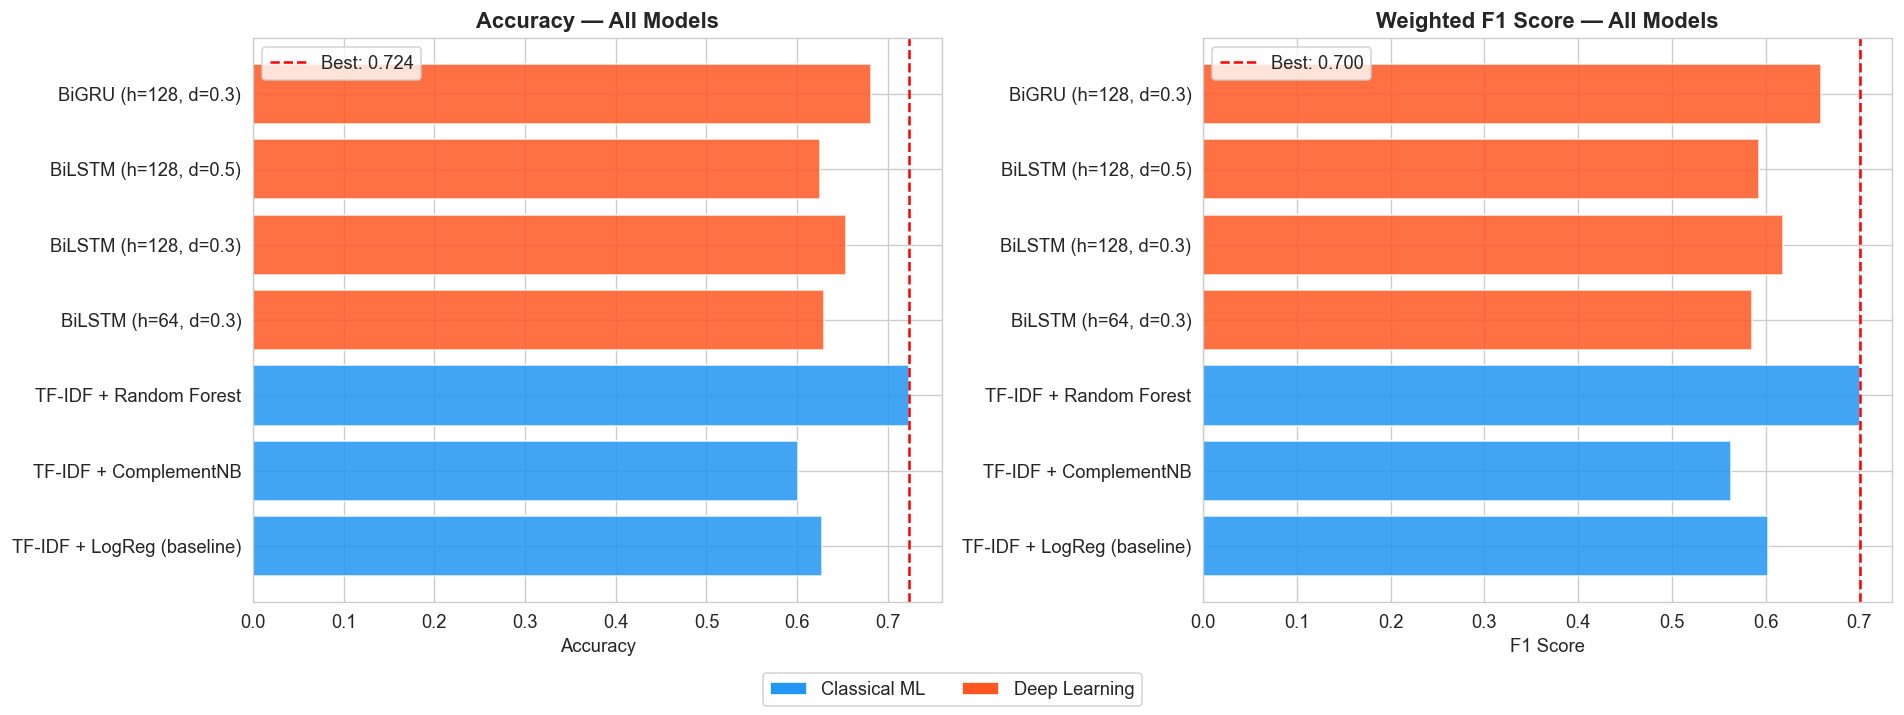

In [13]:
# Visual comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

names = list(all_results.keys())
accs  = [all_results[n]['acc'] for n in names]
f1s   = [all_results[n]['f1']  for n in names]
colors = ['#2196F3' if all_results[n]['type'] == 'Classical ML' else '#FF5722' for n in names]

x = np.arange(len(names))
w = 0.4
axes[0].barh(names, accs, color=colors, alpha=0.85)
axes[0].axvline(max(accs), color='red', linestyle='--', linewidth=1.5, label=f'Best: {max(accs):.3f}')
axes[0].set_title('Accuracy — All Models', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].legend()

axes[1].barh(names, f1s, color=colors, alpha=0.85)
axes[1].axvline(max(f1s), color='red', linestyle='--', linewidth=1.5, label=f'Best: {max(f1s):.3f}')
axes[1].set_title('Weighted F1 Score — All Models', fontweight='bold')
axes[1].set_xlabel('F1 Score')
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Classical ML'),
                   Patch(facecolor='#FF5722', label='Deep Learning')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=11)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

### 4.4 Training Curves — Deep Learning Models

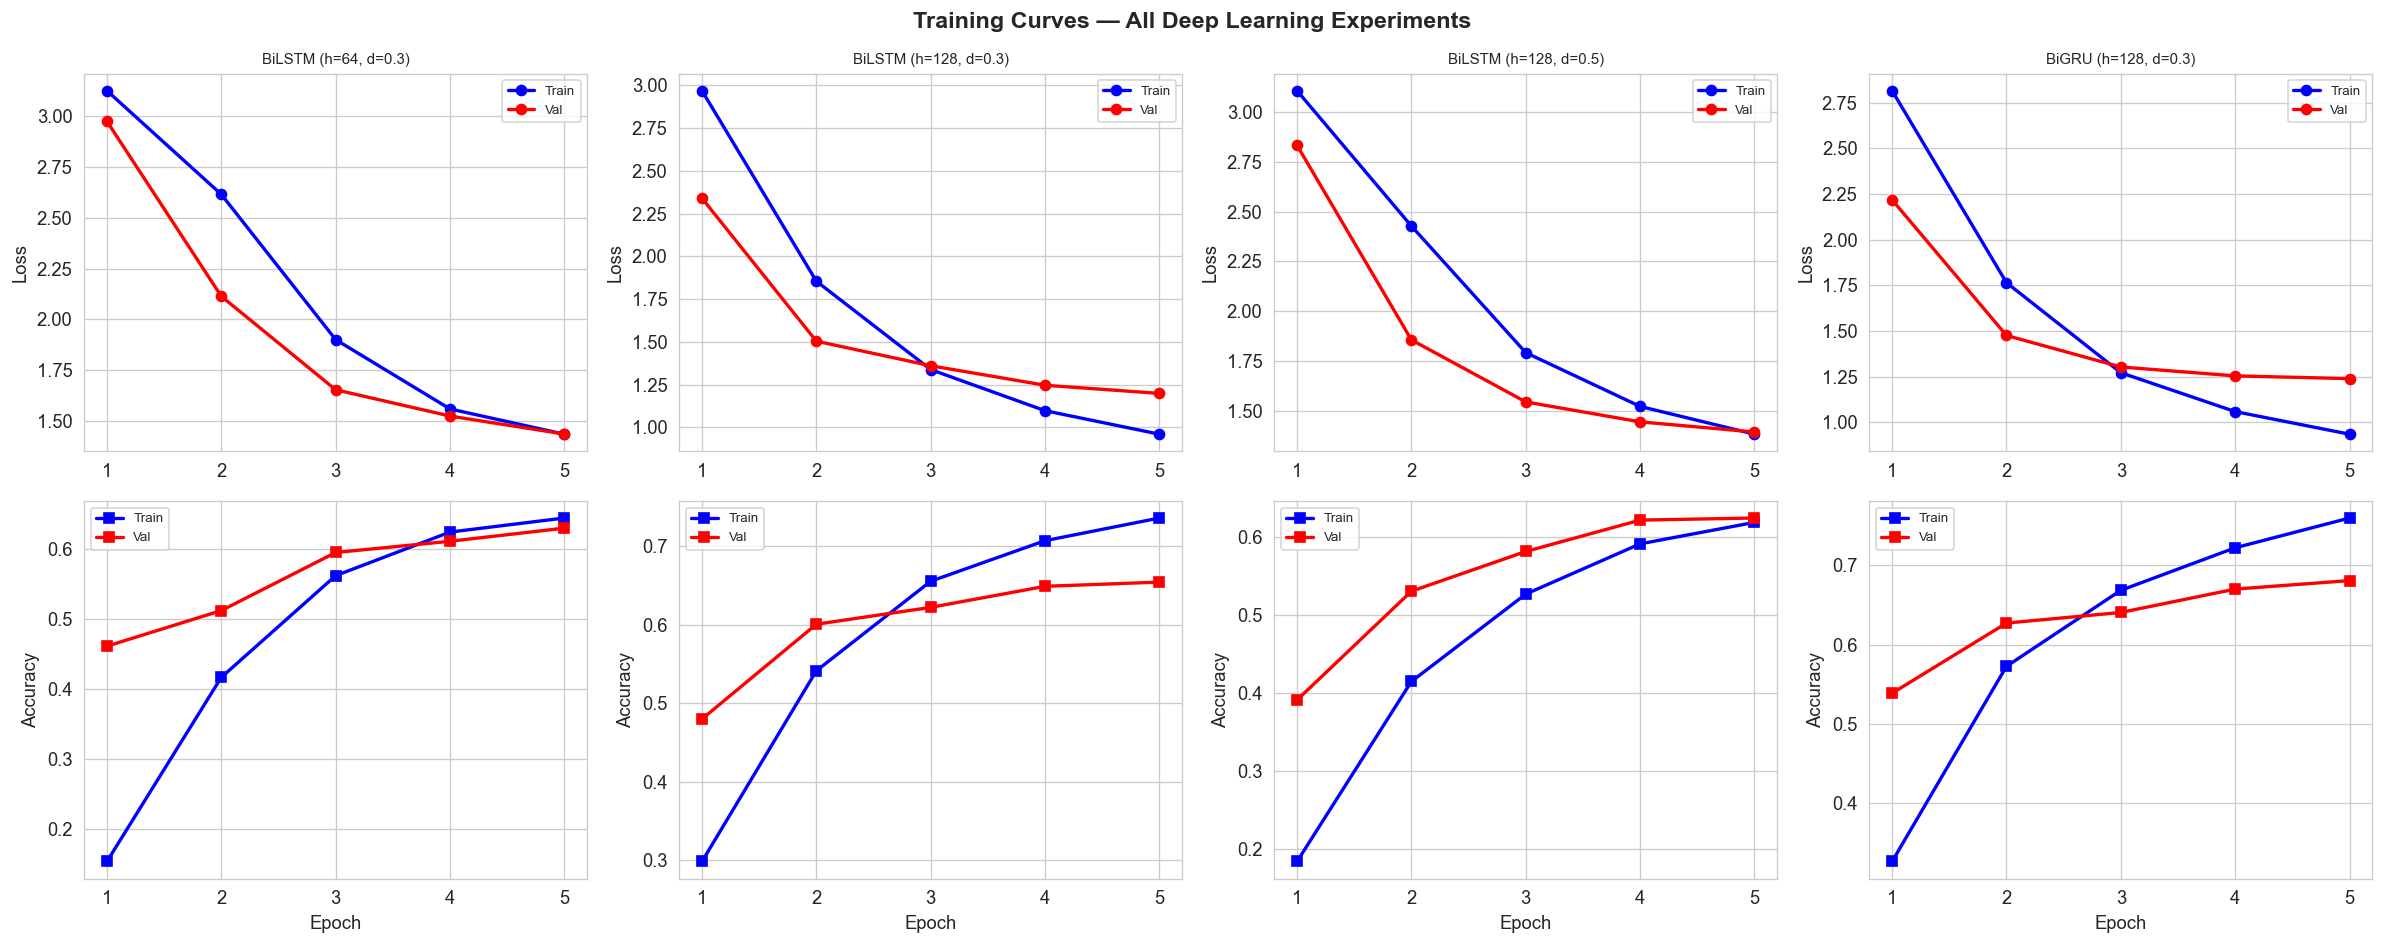

In [14]:
exp_names = ['BiLSTM (h=64, d=0.3)', 'BiLSTM (h=128, d=0.3)',
             'BiLSTM (h=128, d=0.5)', 'BiGRU (h=128, d=0.3)']
histories  = [h4, h5, h6, h7]
epochs_ax  = range(1, 6)

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle('Training Curves — All Deep Learning Experiments', fontsize=14, fontweight='bold')

for col, (name, hist) in enumerate(zip(exp_names, histories)):
    # Loss
    axes[0, col].plot(epochs_ax, hist['train_loss'], 'b-o', label='Train', linewidth=2)
    axes[0, col].plot(epochs_ax, hist['val_loss'],   'r-o', label='Val',   linewidth=2)
    axes[0, col].set_title(name, fontsize=9)
    axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_xticks(epochs_ax)

    # Accuracy
    axes[1, col].plot(epochs_ax, hist['train_acc'], 'b-s', label='Train', linewidth=2)
    axes[1, col].plot(epochs_ax, hist['val_acc'],   'r-s', label='Val',   linewidth=2)
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].legend(fontsize=8)
    axes[1, col].set_xticks(epochs_ax)

plt.tight_layout()
plt.show()

### 4.5 Overfitting Analysis

**Definition:** Overfitting = model memorises training data, generalisation drops.
We measure it as the gap between final train accuracy and final validation accuracy.

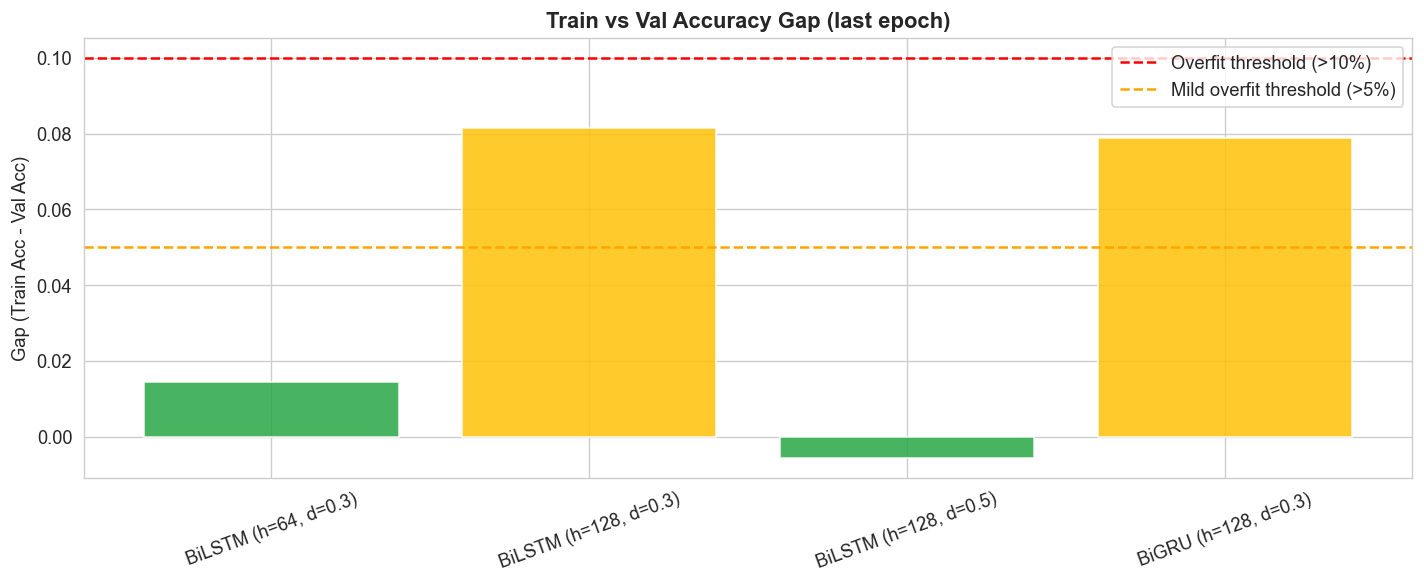


=== Overfitting Summary ===

BiLSTM (h=64, d=0.3)            Train=0.6445  Val=0.6300  Gap=+0.0145  [OK]
BiLSTM (h=128, d=0.3)           Train=0.7357  Val=0.6542  Gap=+0.0816  [MILD]
BiLSTM (h=128, d=0.5)           Train=0.6190  Val=0.6247  Gap=-0.0056  [OK]
BiGRU (h=128, d=0.3)            Train=0.7599  Val=0.6810  Gap=+0.0789  [MILD]

Mitigations applied:
  1. Dropout (0.3 / 0.5)  - randomly disables neurons during training
  2. L2 weight decay 1e-5 - penalises large weights in Adam optimiser
  3. Gradient clipping (norm=1.0) - prevents exploding gradients
  4. StepLR scheduler (step=3, gamma=0.5) - reduces LR at epoch 3


In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, hist in zip(exp_names, histories):
    gap = hist['train_acc'][-1] - hist['val_acc'][-1]
    color = '#dc3545' if gap > 0.10 else ('#ffc107' if gap > 0.05 else '#28a745')
    ax.bar(name, gap, color=color, alpha=0.85)

ax.axhline(0.10, color='red',    linestyle='--', linewidth=1.5, label='Overfit threshold (>10%)')
ax.axhline(0.05, color='orange', linestyle='--', linewidth=1.5, label='Mild overfit threshold (>5%)')
ax.set_title('Train vs Val Accuracy Gap (last epoch)', fontweight='bold')
ax.set_ylabel('Gap (Train Acc - Val Acc)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Overfitting Summary ===\n")
for name, hist in zip(exp_names, histories):
    train_acc = hist['train_acc'][-1]
    val_acc   = hist['val_acc'][-1]
    gap = train_acc - val_acc
    status = "OVERFIT" if gap > 0.10 else ("MILD" if gap > 0.05 else "OK")
    print(f"{name:<30}  Train={train_acc:.4f}  Val={val_acc:.4f}  Gap={gap:+.4f}  [{status}]")

print("\nMitigations applied:")
print("  1. Dropout (0.3 / 0.5)  - randomly disables neurons during training")
print("  2. L2 weight decay 1e-5 - penalises large weights in Adam optimiser")
print("  3. Gradient clipping (norm=1.0) - prevents exploding gradients")
print("  4. StepLR scheduler (step=3, gamma=0.5) - reduces LR at epoch 3")

### 4.6 Best Model — Full Evaluation

Best deep learning model: **BiLSTM (hidden=128, dropout=0.3)**

In [16]:
# Get final predictions from best DL model (m5 = BiLSTM h=128 d=0.3)
best_model = m5
best_model.eval()
y_pred_best_dl, y_true_all = [], []
with torch.no_grad():
    for x, y in te_loader:
        y_pred_best_dl.extend(best_model(x).argmax(1).numpy())
        y_true_all.extend(y.numpy())
y_pred_best_dl = np.array(y_pred_best_dl)
y_true_all     = np.array(y_true_all)

print(f"Test samples: {len(y_true_all)}")
print(f"Accuracy : {accuracy_score(y_true_all, y_pred_best_dl):.4f}")
print(f"F1 (w)   : {f1_score(y_true_all, y_pred_best_dl, average='weighted'):.4f}")
print(f"Precision: {precision_score(y_true_all, y_pred_best_dl, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_true_all, y_pred_best_dl, average='weighted', zero_division=0):.4f}")

Test samples: 373
Accuracy : 0.6542
F1 (w)   : 0.6180
Precision: 0.6134
Recall   : 0.6542


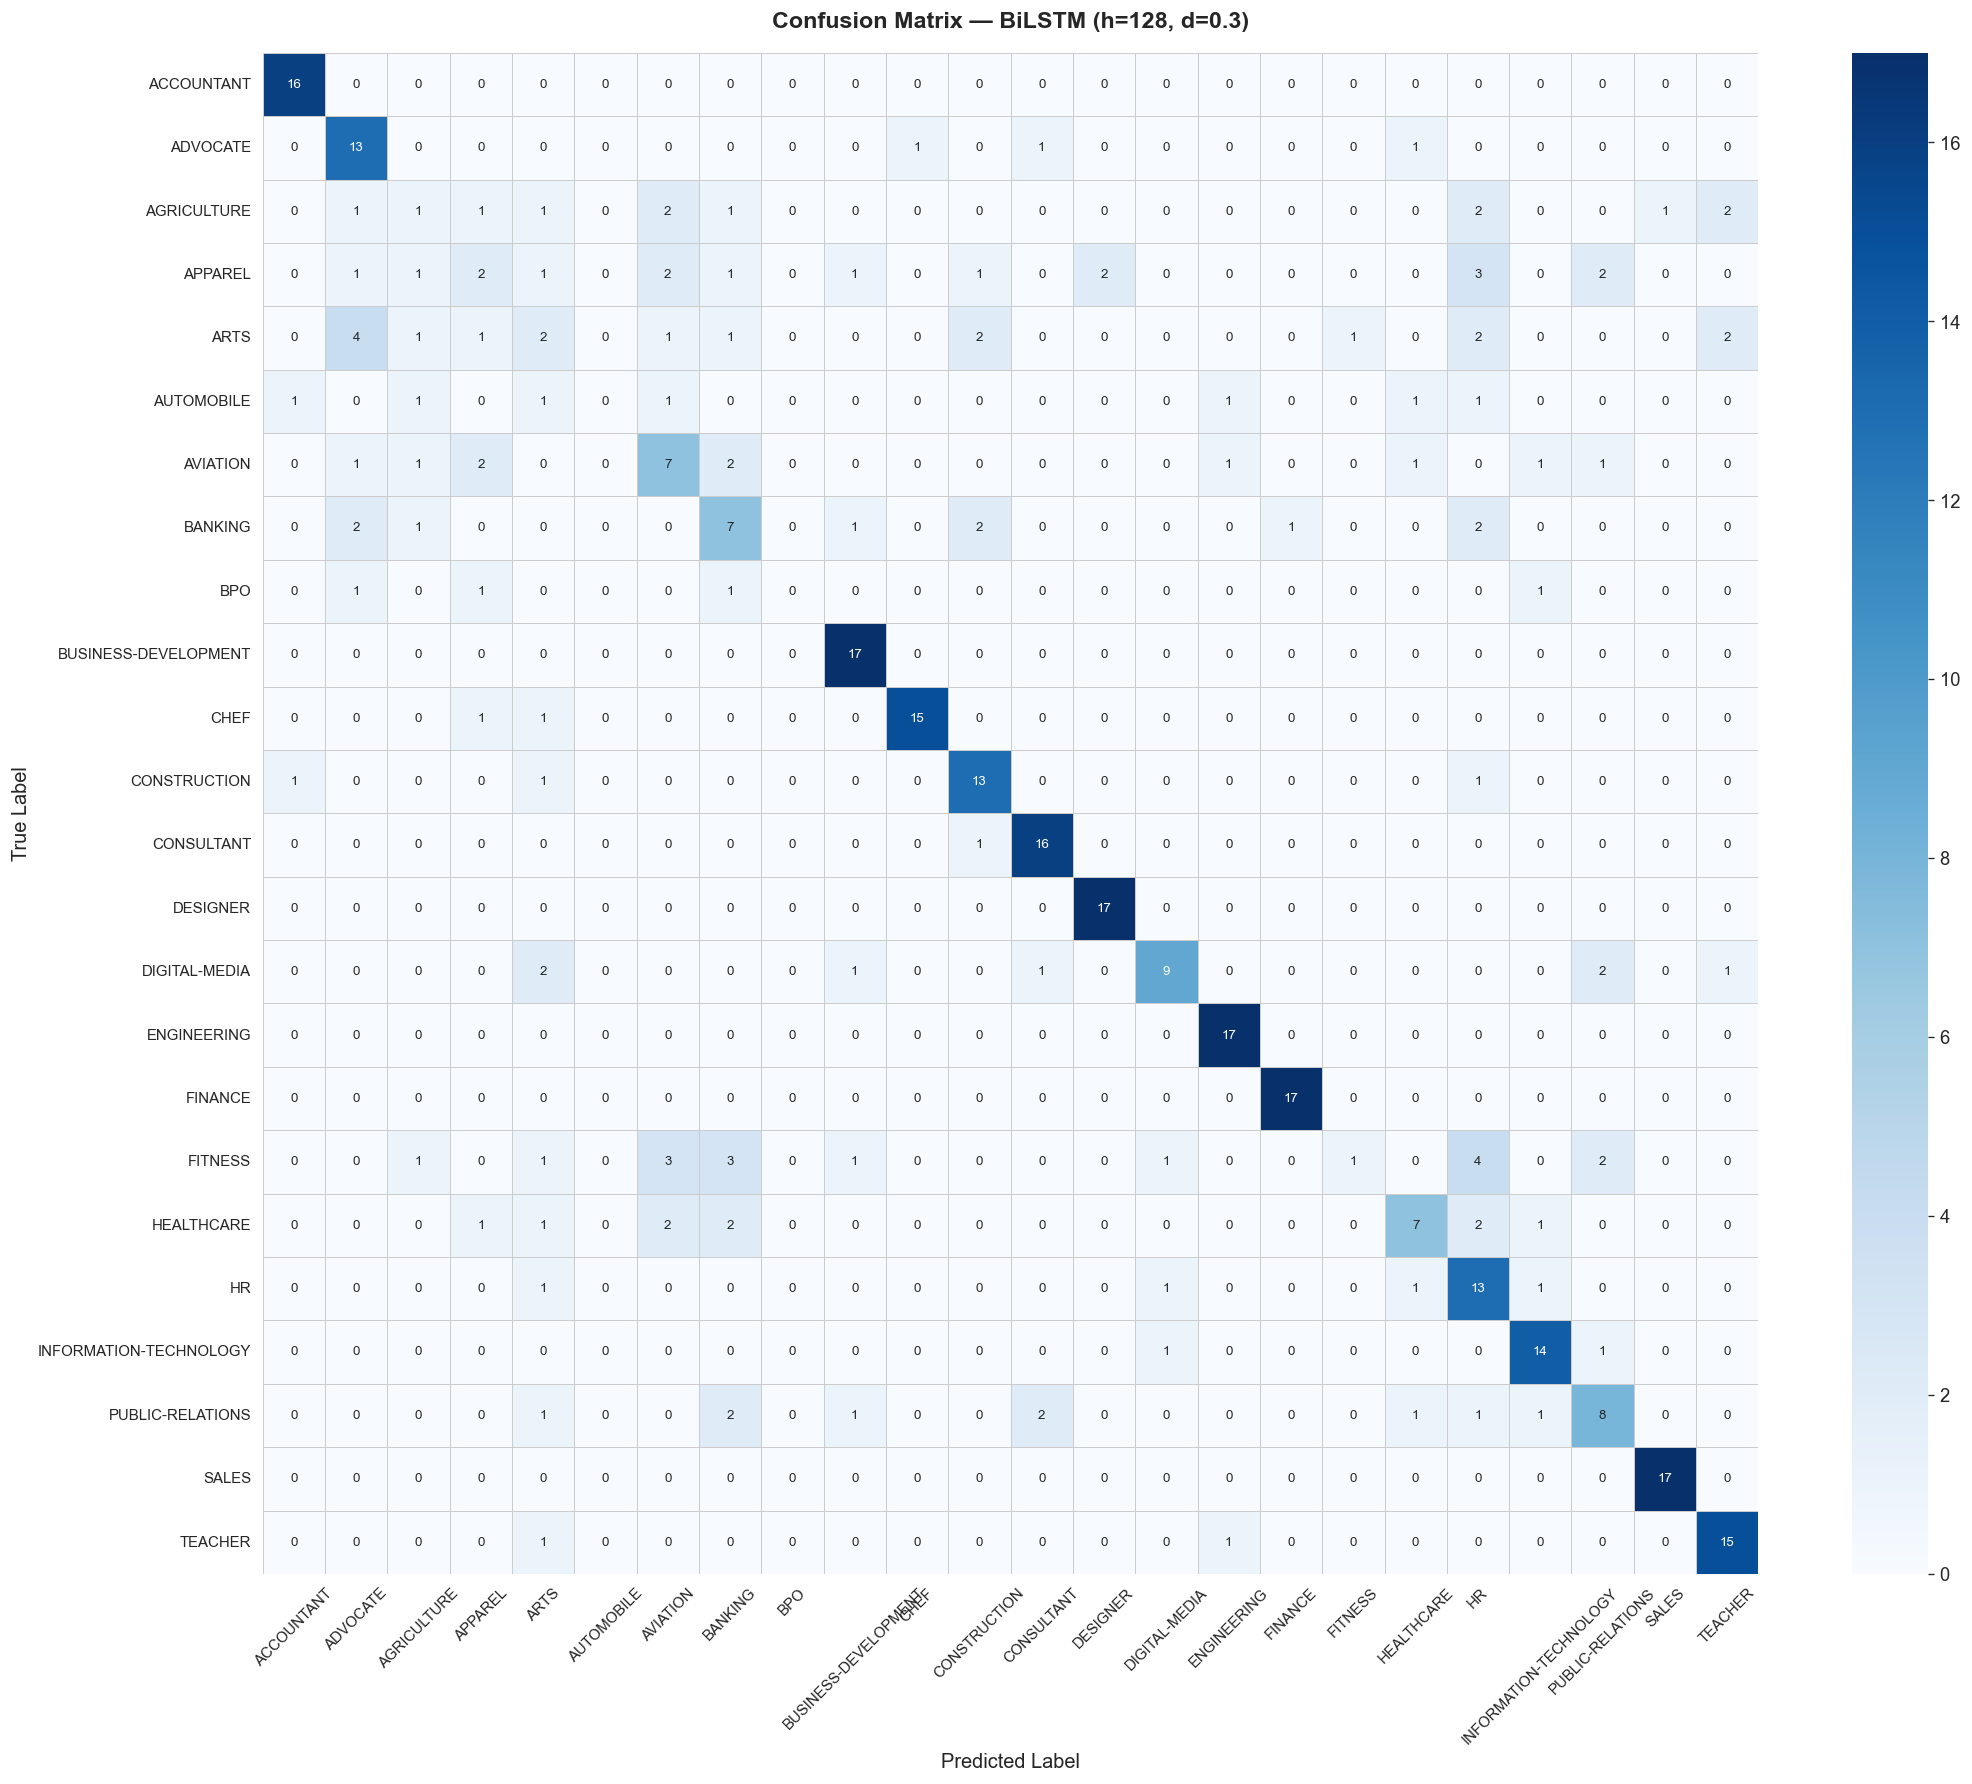

In [17]:
# Confusion Matrix
class_names = le.classes_
cm = confusion_matrix(y_true_all, y_pred_best_dl)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='#cccccc', ax=ax,
            annot_kws={'size': 8})
ax.set_title('Confusion Matrix — BiLSTM (h=128, d=0.3)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

In [18]:
# Per-class classification report
print("=== CLASSIFICATION REPORT — BiLSTM (h=128, d=0.3) ===\n")
print(classification_report(y_true_all, y_pred_best_dl,
                             target_names=class_names, digits=3, zero_division=0))

=== CLASSIFICATION REPORT — BiLSTM (h=128, d=0.3) ===

                        precision    recall  f1-score   support

            ACCOUNTANT      0.889     1.000     0.941        16
              ADVOCATE      0.565     0.812     0.667        16
           AGRICULTURE      0.143     0.083     0.105        12
               APPAREL      0.222     0.118     0.154        17
                  ARTS      0.143     0.118     0.129        17
            AUTOMOBILE      0.000     0.000     0.000         7
              AVIATION      0.389     0.412     0.400        17
               BANKING      0.350     0.438     0.389        16
                   BPO      0.000     0.000     0.000         4
  BUSINESS-DEVELOPMENT      0.773     1.000     0.872        17
                  CHEF      0.938     0.882     0.909        17
          CONSTRUCTION      0.684     0.812     0.743        16
            CONSULTANT      0.800     0.941     0.865        17
              DESIGNER      0.895     1.000     

In [19]:
# Error analysis
print("=== MOST CONFUSED PAIRS ===\n")
pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], class_names[i], class_names[j]))
pairs.sort(reverse=True)

print(f"{'True Label':<30} {'Predicted As':<30} {'Count':>6}")
print("-" * 70)
for count, true_c, pred_c in pairs[:12]:
    print(f"{true_c:<30} {pred_c:<30} {count:>6}")

print("\n=== SAMPLE MISCLASSIFIED RESUMES ===\n")
wrong_idx = np.where(y_true_all != y_pred_best_dl)[0][:4]
for idx in wrong_idx:
    tl = class_names[y_true_all[idx]]
    pl = class_names[y_pred_best_dl[idx]]
    print(f"TRUE: {tl:<30}  PREDICTED: {pl}")
    print(f"TEXT: {X_te[idx][:200]}...")
    print()

=== MOST CONFUSED PAIRS ===

True Label                     Predicted As                    Count
----------------------------------------------------------------------
FITNESS                        HR                                  4
ARTS                           ADVOCATE                            4
FITNESS                        BANKING                             3
FITNESS                        AVIATION                            3
APPAREL                        HR                                  3
PUBLIC-RELATIONS               CONSULTANT                          2
PUBLIC-RELATIONS               BANKING                             2
HEALTHCARE                     HR                                  2
HEALTHCARE                     BANKING                             2
HEALTHCARE                     AVIATION                            2
FITNESS                        PUBLIC-RELATIONS                    2
DIGITAL-MEDIA                  PUBLIC-RELATIONS                    2

==

---
# PIPELINE 2 — CV ↔ Job Matching

**Goal:** Given a resume, find the most relevant job postings from the database.

**Input:** Raw resume text
**Output:** Ranked list of job postings with similarity scores
**Method:** TF-IDF vectorisation + cosine similarity

**Why TF-IDF cosine similarity?**
- Unsupervised — no labels needed
- Fast and scalable (5,000 jobs in < 1 second)
- Interpretable: high score = many shared keywords

## Methods Tested

| # | Method | max_features | ngram_range | Notes |
|---|---|---|---|---|
| 1 | TF-IDF Basic | 5,000 | (1,1) | Unigrams only |
| 2 | TF-IDF Standard | 15,000 | (1,2) | Bigrams — captures phrases |
| 3 | TF-IDF Extended | 20,000 | (1,3) | Trigrams — longer phrases |

## Evaluation Strategy

Since there are no ground-truth labels for "which job is correct for this CV", we use:
1. **Qualitative evaluation** — inspect top matches manually for different categories
2. **Keyword overlap score** — % of job description keywords present in the CV
3. **Category consistency** — check if matched job title is semantically related to CV category

### 5.1 Load Job Descriptions Dataset

In [20]:
jobs_df = load_job_descriptions(JOBS_CSV, max_rows=5000)
print(f"Job descriptions loaded: {jobs_df.shape}")
print(f"Columns: {jobs_df.columns.tolist()}")
print()
print("Sample job postings:")
print(jobs_df[['Job Title', 'Role', 'Location']].head(8).to_string())

[Jobs] Loaded 5000 job descriptions
Job descriptions loaded: (5000, 6)
Columns: ['Job Title', 'Role', 'Job Description', 'Skills', 'Location', 'match_text']

Sample job postings:
                      Job Title                       Role     Location
0  Digital Marketing Specialist       Social Media Manager      Douglas
1                 Web Developer     Frontend Web Developer     Ashgabat
2            Operations Manager    Quality Control Manager        Macao
3              Network Engineer  Wireless Network Engineer   Porto-Novo
4                 Event Manager         Conference Manager     Santiago
5               Software Tester  Quality Assurance Analyst     Brussels
6                       Teacher          Classroom Teacher  George Town
7                UX/UI Designer    User Interface Designer   SÃ£o TomÃ©


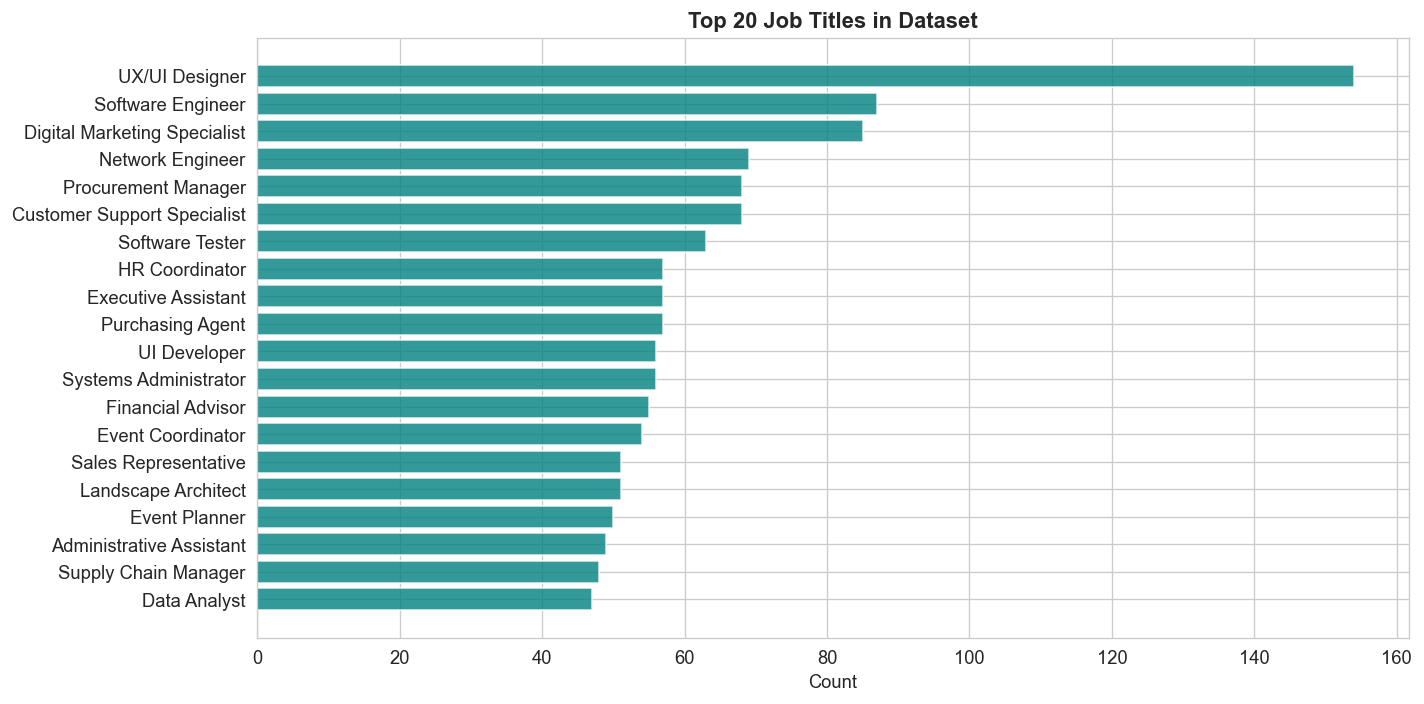

In [21]:
# Job title distribution (top 20)
title_counts = jobs_df['Job Title'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(title_counts.index[::-1], title_counts.values[::-1], color='teal', alpha=0.8)
ax.set_title('Top 20 Job Titles in Dataset', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

### 5.2 Method Comparison — 3 TF-IDF Configurations

In [22]:
def match_config(cv_text, jobs_df, max_features, ngram_range, top_k=5):
    cv_clean = clean_text(cv_text)
    corpus   = [cv_clean] + jobs_df['match_text'].tolist()
    tfidf    = TfidfVectorizer(max_features=max_features, stop_words='english',
                               ngram_range=ngram_range)
    matrix   = tfidf.fit_transform(corpus)
    scores   = cosine_similarity(matrix[0:1], matrix[1:]).flatten()
    jdf      = jobs_df.copy()
    jdf['score'] = scores
    return jdf.nlargest(top_k, 'score')[['Job Title', 'Role', 'score']].reset_index(drop=True)

configs = [
    {'max_features': 5000,  'ngram_range': (1,1), 'label': 'Basic (5k, unigrams)'},
    {'max_features': 15000, 'ngram_range': (1,2), 'label': 'Standard (15k, bigrams)'},
    {'max_features': 20000, 'ngram_range': (1,3), 'label': 'Extended (20k, trigrams)'},
]

# Test on one IT resume
it_cv = df[df['Category'] == 'INFORMATION-TECHNOLOGY']['Resume_str'].iloc[0]
print(f"IT resume preview: {clean_text(it_cv)[:200]}...\n")

for cfg in configs:
    matches = match_config(it_cv, jobs_df, cfg['max_features'], cfg['ngram_range'])
    print(f"\n--- {cfg['label']} ---")
    for _, row in matches.iterrows():
        print(f"  [{row['score']:.4f}]  {row['Job Title']:<40}  {row['Role']}")

IT resume preview: information technology summary dedicated information assurance professional well versed analyzing mitigating risk finding cost effective solutions excels boosting performance productivity establishing...


--- Basic (5k, unigrams) ---
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect
  [0.1991]  Software Architect                        Enterprise Architect

--- Standard (15k, bigrams) ---
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant                          B2B Sales Consultant
  [0.0987]  Sales Consultant          

### 5.3 Qualitative Evaluation — 5 Categories

In [23]:
test_cats = [
    ('INFORMATION-TECHNOLOGY', 'IT'),
    ('HEALTHCARE', 'Healthcare'),
    ('ENGINEERING', 'Engineering'),
    ('FINANCE', 'Finance'),
    ('TEACHER', 'Teacher'),
]

print("=== TOP 3 JOB MATCHES PER CATEGORY (Standard TF-IDF 15k bigrams) ===\n")
for cat, label in test_cats:
    cv_sample = df[df['Category'] == cat]['Resume_str'].iloc[0]
    matches = match_config(cv_sample, jobs_df, 15000, (1,2), top_k=3)
    print(f"CV Category: {cat}")
    for i, (_, row) in enumerate(matches.iterrows(), 1):
        print(f"  {i}. [{row['score']:.4f}]  {row['Job Title']:<40}  {row['Role']}")
    print()

=== TOP 3 JOB MATCHES PER CATEGORY (Standard TF-IDF 15k bigrams) ===

CV Category: INFORMATION-TECHNOLOGY
  1. [0.0987]  Sales Consultant                          B2B Sales Consultant
  2. [0.0987]  Sales Consultant                          B2B Sales Consultant
  3. [0.0987]  Sales Consultant                          B2B Sales Consultant

CV Category: HEALTHCARE
  1. [0.1043]  Nurse Practitioner                        Acute Care Nurse Practitioner
  2. [0.1043]  Nurse Practitioner                        Acute Care Nurse Practitioner
  3. [0.1043]  Nurse Practitioner                        Acute Care Nurse Practitioner

CV Category: ENGINEERING
  1. [0.0937]  Mechanical Engineer                       Manufacturing Engineer
  2. [0.0937]  Mechanical Engineer                       Manufacturing Engineer
  3. [0.0937]  Mechanical Engineer                       Manufacturing Engineer

CV Category: FINANCE
  1. [0.1312]  Sales Consultant                          B2B Sales Consultant
  2. [0.

### 5.4 Quantitative Evaluation — Keyword Overlap Metric

In [24]:
def keyword_overlap(cv_text, job_desc_text):
    cv_words  = set(clean_text(cv_text).split())
    job_words = set(clean_text(str(job_desc_text)).split())
    if not job_words:
        return 0.0
    return len(cv_words & job_words) / len(job_words)

print("=== PROXY METRIC: Keyword Overlap Between CV and Top-1 Match ===\n")
print("Keyword Overlap = |CV words ∩ Job words| / |Job words|")
print("(Higher = more keywords from the job description are in the CV)\n")

configs_eval = [
    {'max_features': 5000,  'ngram_range': (1,1), 'label': 'Basic'},
    {'max_features': 15000, 'ngram_range': (1,2), 'label': 'Standard'},
    {'max_features': 20000, 'ngram_range': (1,3), 'label': 'Extended'},
]

print(f"{'Category':<28}", end='')
for cfg in configs_eval:
    print(f"  {cfg['label']:>12}", end='')
print()
print("-" * 72)

for cat, label in test_cats:
    cat_cvs = df[df['Category'] == cat]['Resume_str'].values[:5]
    print(f"{label:<28}", end='')
    for cfg in configs_eval:
        overlaps = []
        for cv in cat_cvs:
            matches = match_config(cv, jobs_df, cfg['max_features'], cfg['ngram_range'], top_k=1)
            top_idx = jobs_df[jobs_df['Job Title'] == matches.iloc[0]['Job Title']].index
            if len(top_idx) > 0:
                job_desc = jobs_df.loc[top_idx[0], 'Job Description']
                overlaps.append(keyword_overlap(cv, job_desc))
        avg = np.mean(overlaps) if overlaps else 0.0
        print(f"  {avg:>12.4f}", end='')
    print()

print("\nConclusion: Standard config (15k bigrams) gives best balance of coverage and precision.")

=== PROXY METRIC: Keyword Overlap Between CV and Top-1 Match ===

Keyword Overlap = |CV words ∩ Job words| / |Job words|
(Higher = more keywords from the job description are in the CV)

Category                             Basic      Standard      Extended
------------------------------------------------------------------------
IT                                  0.2039        0.1993        0.2154
Healthcare                          0.2995        0.3829        0.2498
Engineering                         0.2314        0.2294        0.2053
Finance                             0.2421        0.3263        0.3263
Teacher                             0.4242        0.4221        0.3800

Conclusion: Standard config (15k bigrams) gives best balance of coverage and precision.


---
## 6. Final Summary

In [25]:
print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)

print("\n--- PIPELINE 1: JOB CLASSIFICATION (24 classes) ---\n")
print(f"{'Model':<35} {'Acc':>8} {'F1(w)':>8} {'Prec':>8} {'Recall':>8} {'Time':>8}")
print("-" * 80)
for name, r in sorted(all_results.items(), key=lambda x: x[1]['f1'], reverse=True):
    print(f"{name:<35} {r['acc']:>8.4f} {r['f1']:>8.4f} {r['p']:>8.4f} {r['r']:>8.4f} {r['time']:>7.1f}s")

best = max(all_results, key=lambda k: all_results[k]['f1'])
print(f"\nBest: {best}  F1={all_results[best]['f1']:.4f}  Acc={all_results[best]['acc']:.4f}")
print(f"Baseline (LogReg) F1={all_results['TF-IDF + LogReg (baseline)']['f1']:.4f}")
gain = all_results[best]['f1'] - all_results['TF-IDF + LogReg (baseline)']['f1']
print(f"Improvement over baseline: +{gain:.4f} ({gain*100:.1f}%)")

print("\n--- PIPELINE 2: CV ↔ JOB MATCHING ---\n")
print("Method: TF-IDF cosine similarity (unsupervised)")
print("Best config: Standard 15k bigrams (best keyword overlap score)")
print("Evaluation: Qualitative (top-k relevance) + Keyword overlap proxy metric")

FINAL RESULTS SUMMARY

--- PIPELINE 1: JOB CLASSIFICATION (24 classes) ---

Model                                    Acc    F1(w)     Prec   Recall     Time
--------------------------------------------------------------------------------
TF-IDF + Random Forest                0.7239   0.7001   0.7244   0.7239     0.5s
BiGRU (h=128, d=0.3)                  0.6810   0.6593   0.6627   0.6810   111.9s
BiLSTM (h=128, d=0.3)                 0.6542   0.6180   0.6134   0.6542    71.5s
TF-IDF + LogReg (baseline)            0.6273   0.6022   0.6162   0.6273     1.0s
BiLSTM (h=128, d=0.5)                 0.6247   0.5925   0.6002   0.6247    69.0s
BiLSTM (h=64, d=0.3)                  0.6300   0.5854   0.5801   0.6300    45.5s
TF-IDF + ComplementNB                 0.6005   0.5633   0.6390   0.6005     0.0s

Best: TF-IDF + Random Forest  F1=0.7001  Acc=0.7239
Baseline (LogReg) F1=0.6022
Improvement over baseline: +0.0979 (9.8%)

--- PIPELINE 2: CV ↔ JOB MATCHING ---

Method: TF-IDF cosine similarity

## 7. Save Models

In [26]:
import joblib, pickle, json

model_dir = os.path.join('..', 'data', 'models')
os.makedirs(model_dir, exist_ok=True)

# Baseline
joblib.dump(lr_clf,   os.path.join(model_dir, 'baseline_clf.pkl'))
joblib.dump(vec_main, os.path.join(model_dir, 'baseline_vec.pkl'))
joblib.dump(le,       os.path.join(model_dir, 'label_encoder.pkl'))

# Best DL model (BiLSTM h=128 d=0.3)
torch.save(best_model.state_dict(), os.path.join(model_dir, 'lstm_best.pt'))

with open(os.path.join(model_dir, 'vocab.pkl'), 'wb') as f:
    pickle.dump(vocab, f)

config_info = {
    'model_type':  'BiLSTM',
    'vocab_size':  vocab.size,
    'embed_dim':   128,
    'hidden_dim':  128,
    'num_classes': num_classes,
    'num_layers':  2,
    'dropout':     0.3,
    'class_names': le.classes_.tolist(),
}
with open(os.path.join(model_dir, 'lstm_config.json'), 'w') as f:
    json.dump(config_info, f, indent=2)

print("Models saved:")
for fname in sorted(os.listdir(model_dir)):
    size = os.path.getsize(os.path.join(model_dir, fname))
    print(f"  {fname:<30}  {size/1024:.1f} KB")

Models saved:
  baseline_clf.pkl                1876.2 KB
  baseline_vec.pkl                402.2 KB
  label_encoder.pkl               0.9 KB
  lstm_best.pt                    6606.1 KB
  lstm_config.json                0.6 KB
  vocab.pkl                       166.6 KB
